# Results Figures

One figure per section, each in its own cell so you can rerun any single one
independently after running the Config cell once. Run **Config** first,
then **Path check** to confirm your folder layout matches before running any
figure cell.

Figures save to `PROJECT_ROOT/results_figures/`.


In [103]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# CONFIG - run this cell once per session before any figure cell.
#
# Assumes this notebook lives in your "Scripts" folder, same as your other
# scripts (15-RandomForest.py etc.) - PROJECT_ROOT is one level up.
#
# All paths below are confirmed against your actual folder structure.
# ============================================================
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_DIR = PROJECT_ROOT                                    # confirmed via path-check
RING_DIR = PROJECT_ROOT / "RING"                           # confirmed via folder screenshot
QC_FIGURES_DIR = PROJECT_ROOT / "output" / "figures"       # confirmed: loose files here, not the per-sequence subfolders

PERFORMANCE_DIR = PROJECT_ROOT / "performance"
DYNAMICS_DIR = PROJECT_ROOT / "figures" / "hotspot_vs_nonhotspot"
FEATURE_SELECTION_DIR = PROJECT_ROOT / "feature_selection"
PARAMETERS_CSV_DIR = PROJECT_ROOT / "parameters_csv"

# merged_output.csv sits in the Scripts folder itself, alongside this notebook.
SCRIPTS_DIR = NOTEBOOK_DIR
MERGED_OUTPUT_PATH = SCRIPTS_DIR / "merged_output.csv"

FIG_OUT_DIR = PROJECT_ROOT / "results_figures"
FIG_OUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
HOTSPOT_COLOUR = "#d62728"
NONHOTSPOT_COLOUR = "#1f77b4"

hotspot_map = {
    "APC_637": 1, "APC_641": 0, "APC_3335": 0, "APC_3340": 1,
    "APC_4099": 1, "APC_4103": 0, "APC_4343": 0, "APC_4348": 1,
    "TP53_632": 0, "TP53_637": 1, "TP53_844": 1, "TP53_849": 0,
}

print("Config loaded. PROJECT_ROOT =", PROJECT_ROOT.resolve())


Config loaded. PROJECT_ROOT = C:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation


In [104]:
# ============================================================
# PATH CHECK - run once after Config to confirm your layout matches
# before running any figure cell below.
# ============================================================
_checks = {
    "DATA_DIR / APC_Colorectal_Adenocarcinoma.csv": DATA_DIR / "APC_Colorectal_Adenocarcinoma.csv",
    "MERGED_OUTPUT_PATH": MERGED_OUTPUT_PATH,
    "RING_DIR / hotspot_vs_nonhotspot_stats.csv": RING_DIR / "hotspot_vs_nonhotspot_stats.csv",
    "RING_DIR / per_sequence_averaged.csv": RING_DIR / "per_sequence_averaged.csv",
    "PERFORMANCE_DIR / RF_performance.csv": PERFORMANCE_DIR / "RF_performance.csv",
    "DYNAMICS_DIR / dynamics_group_comparison_stats.csv": DYNAMICS_DIR / "dynamics_group_comparison_stats.csv",
    "FEATURE_SELECTION_DIR / shared/Lasso/Lasso_summary.csv": FEATURE_SELECTION_DIR / "shared" / "Lasso" / "Lasso_summary.csv",
    "FEATURE_SELECTION_DIR / rf/RFCI/RF_RFCI_summary.csv": FEATURE_SELECTION_DIR / "rf" / "RFCI" / "RF_RFCI_summary.csv",
    "QC_FIGURES_DIR / rmsd_backbone_timeseries.pdf": QC_FIGURES_DIR / "rmsd_backbone_timeseries.pdf",
}
for label, path in _checks.items():
    status = "\u2713" if path.exists() else "\u2717 MISSING"
    print(f"{status:12s} {label}  ->  {path}")


✓            DATA_DIR / APC_Colorectal_Adenocarcinoma.csv  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation\APC_Colorectal_Adenocarcinoma.csv
✓            MERGED_OUTPUT_PATH  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation\Scripts\merged_output.csv
✓            RING_DIR / hotspot_vs_nonhotspot_stats.csv  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation\RING\hotspot_vs_nonhotspot_stats.csv
✓            RING_DIR / per_sequence_averaged.csv  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation\RING\per_sequence_averaged.csv
✓            PERFORMANCE_DIR / RF_performance.csv  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertation\performance\RF_performance.csv
✓            DYNAMICS_DIR / dynamics_group_comparison_stats.csv  ->  c:\Users\rache\OneDrive - Cardiff University\MSc Bioinformatics\MET591 Dissertati

## Figure 1 — Mutation lollipop plot (APC/TP53, CRC)

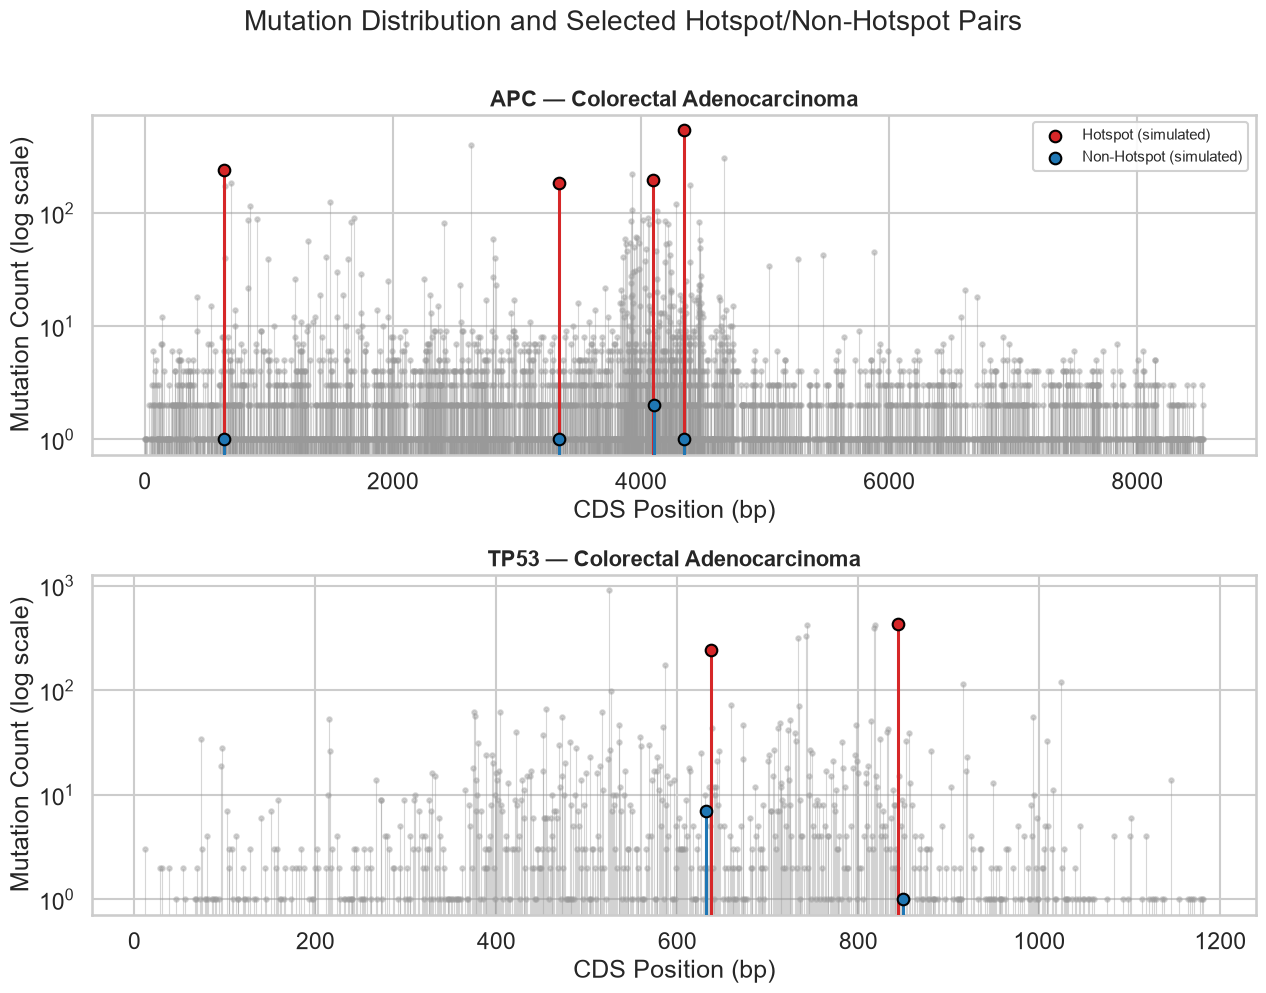

In [105]:
PAIRS = {
    "APC": {"hot": [637, 3340, 4099, 4348], "non": [641, 3335, 4103, 4343]},
    "TP53": {"hot": [637, 844], "non": [632, 849]},
}
BACKGROUND_COLOUR = "#999999"
FILES = {"APC": DATA_DIR / "APC_Colorectal_Adenocarcinoma.csv",
         "TP53": DATA_DIR / "TP53_Colorectal_Adenocarcinoma.csv"}

def load_positions(gene):
    df = pd.read_csv(FILES[gene])
    df["cds_pos"] = df["CDS Mutation"].str.extract(r"c\.(\d+)").astype(float)
    df = df.dropna(subset=["cds_pos"])
    return df.groupby("cds_pos", as_index=False)["Count"].sum()

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
for ax, gene in zip(axes, ["APC", "TP53"]):
    agg = load_positions(gene)
    hot_pos, non_pos = set(PAIRS[gene]["hot"]), set(PAIRS[gene]["non"])
    bg_mask = ~agg["cds_pos"].isin(hot_pos | non_pos)
    ax.vlines(agg["cds_pos"][bg_mask], 0, agg["Count"][bg_mask], color=BACKGROUND_COLOUR, alpha=0.4, lw=0.8, zorder=1)
    ax.scatter(agg["cds_pos"][bg_mask], agg["Count"][bg_mask], color=BACKGROUND_COLOUR, alpha=0.4, s=10, zorder=1)
    for pos_set, colour, label in [(hot_pos, HOTSPOT_COLOUR, "Hotspot (simulated)"),
                                     (non_pos, NONHOTSPOT_COLOUR, "Non-Hotspot (simulated)")]:
        mask = agg["cds_pos"].isin(pos_set)
        ax.vlines(agg["cds_pos"][mask], 0, agg["Count"][mask], color=colour, lw=2.2, zorder=3)
        ax.scatter(agg["cds_pos"][mask], agg["Count"][mask], color=colour, s=70, edgecolor="black", zorder=4, label=label)
    ax.set_yscale("log")
    ax.set_ylabel("Mutation Count (log scale)")
    ax.set_title(f"{gene} \u2014 Colorectal Adenocarcinoma", fontsize=16, fontweight="bold")
    ax.set_xlabel("CDS Position (bp)")
axes[0].legend(loc="upper right", fontsize=11, framealpha=0.9)
fig.suptitle("Mutation Distribution and Selected Hotspot/Non-Hotspot Pairs", fontsize=20, y=1.00)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig1_lollipop.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 2 — MD simulation quality control composite

`QC_FIGURES_DIR` is set to `PROJECT_ROOT/output/figures` — confirmed as the
true all-36-simulation aggregate from `11-visualisation-all.py` (its actual
default `OUT_DIR`). This folder also contains per-sequence subfolders
(`output/figures/APC_641_non/` etc.) written separately by `11-vis-seq.py` -
the cell below reads the loose files directly by name, so it won't
accidentally pick up a subfolder's version.

**This cell needs `poppler` installed and on PATH** (it's what `pdf2image`
shells out to for rendering PDF pages). If you hit
`PDFInfoNotInstalledError`, install it into your conda environment:

```
conda install -c conda-forge poppler
```

(I tried swapping this to the pure-Python `PyMuPDF` library to avoid the
external dependency entirely, but it turned out to be far *slower* on these
specific PDFs - ~29s per page even at minimum resolution, vs. poppler
handling all 4 in well under a minute - so poppler is the better choice
here despite needing a separate install.)

Make sure both `11-visualisation-all.py` and the time-axis fix have been
rerun before trusting this figure - the RMSD panels previously showed a
compressed 0.00–0.30 ns axis instead of the full 0–300 ns.


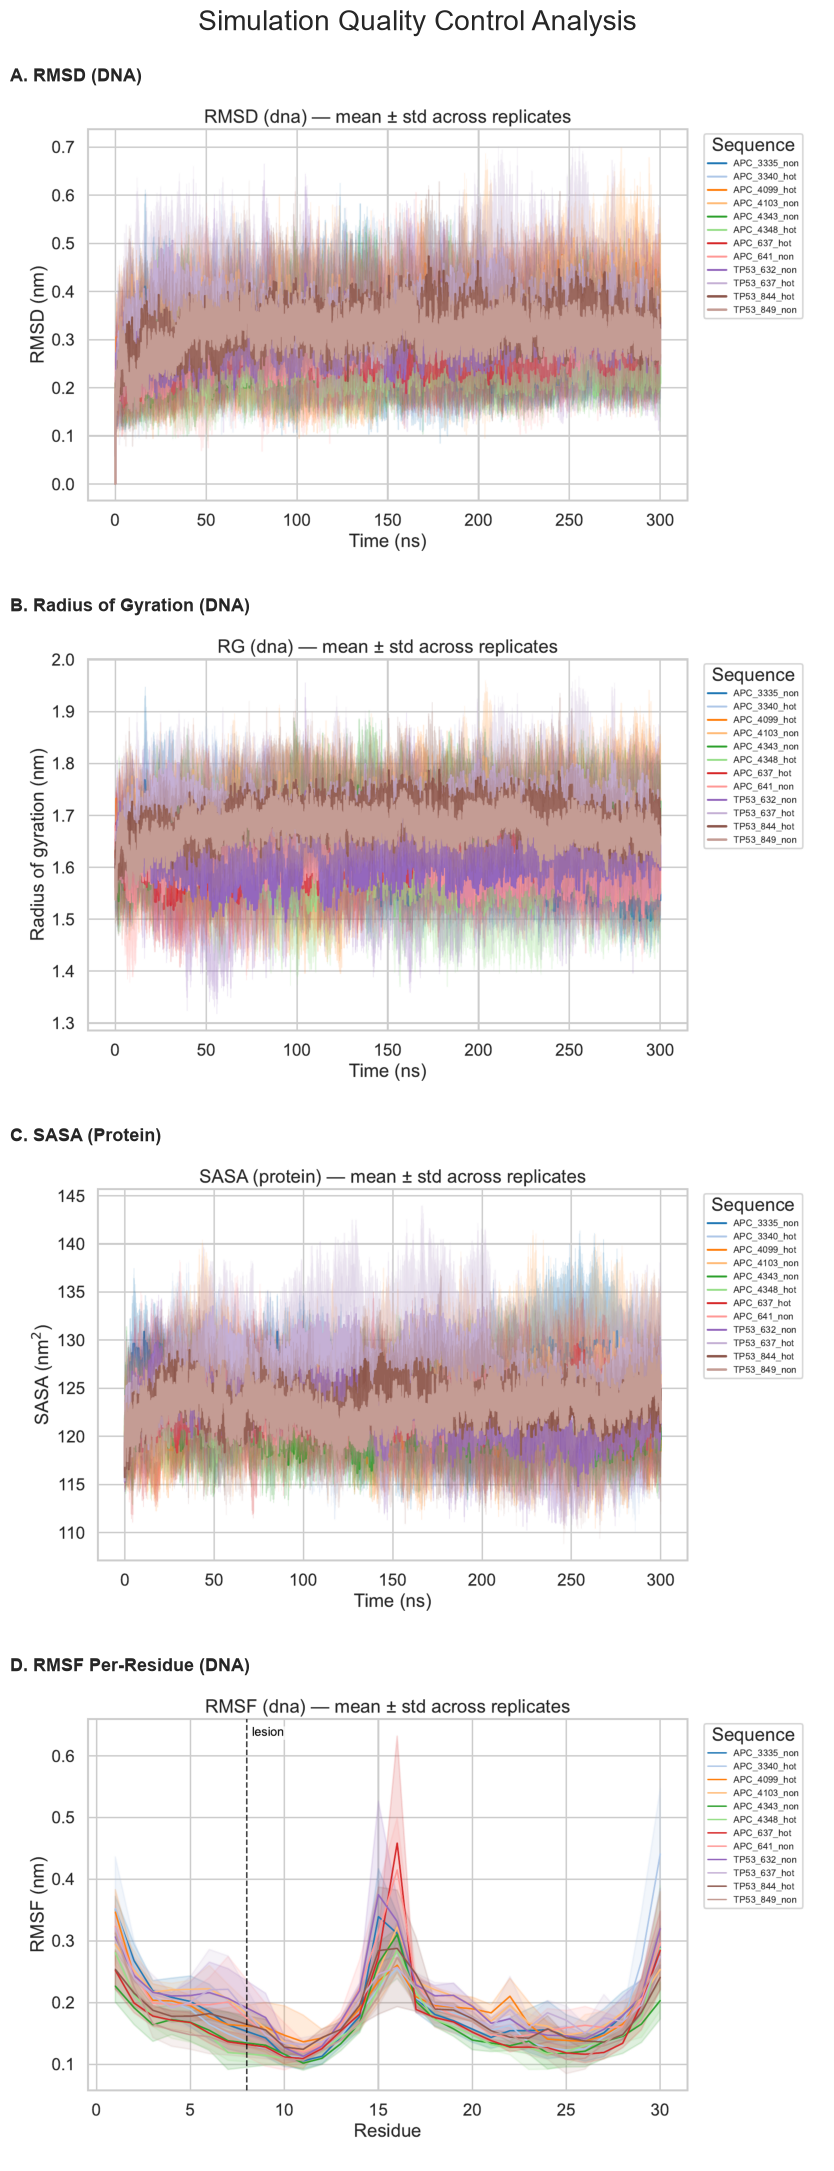

In [113]:
from pdf2image import convert_from_path

SOURCE_PDFS = {
    "A": ("rmsd_dna_timeseries.pdf", "RMSD (DNA)"),
    "B": ("rg_dna_timeseries.pdf", "Radius of Gyration (DNA)"),
    "C": ("sasa_protein_timeseries.pdf", "SASA (Protein)"),
    "D": ("rmsf_dna_perresidue.pdf", "RMSF Per-Residue (DNA)"),
}

fig, axes = plt.subplots(4, 1, figsize=(9, 22))
for ax, panel in zip(axes.flat, ["A", "B", "C", "D"]):
    fname, label = SOURCE_PDFS[panel]
    pages = convert_from_path(QC_FIGURES_DIR / fname, dpi=150)
    ax.imshow(pages[0])
    ax.axis("off")
    ax.set_title(f"{panel}. {label}", fontsize=13, fontweight="bold", loc="left")
fig.suptitle("Simulation Quality Control Analysis", fontsize=20, y=0.99)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig2_qc_composite.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 2 — numeric ranges for RMSD, Rg and SASA

Reads the source `.xvg` files directly (the composite above is rasterised
PDF pages, so no numbers can be recovered from it). Reports both the full
trajectory span and the last 50% only, matching the `EQUIL_FRACTION = 0.5`
used in `11-visualise_hotspot_comparison.py`.

In [ ]:
# ============================================================
# Numeric ranges behind Figure 2 panels A-C.
# Source: PROJECT_ROOT/output/<sequence>/<replicate>/analysis/*.xvg
# ============================================================
XVG_DIR = QC_FIGURES_DIR.parent          # PROJECT_ROOT/output
EQUIL_FRACTION = 0.9                     # matches 11-visualise_hotspot_comparison.py
WANTED = {("rmsd", "dna"), ("rg", "dna"), ("sasa", "protein")}
UNIT = {"rmsd": "nm", "rg": "nm", "sasa": "nm^2"}

def read_xvg(fp):
    rows = []
    with open(fp) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "@")):
                continue
            rows.append([float(x) for x in line.replace(",", " ").split()])
    return np.array(rows) if rows else np.empty((0, 0))

frames, n_seen = [], 0
for fp in XVG_DIR.rglob("*.xvg"):
    if fp.parent.name != "analysis":     # guards against stray .xvg elsewhere
        continue
    n_seen += 1
    metric, _, component = fp.stem.lower().partition("_")
    if (metric, component) not in WANTED:
        continue
    arr = read_xvg(fp)
    if arr.size == 0:
        print(f"WARNING: no data parsed from {fp}")
        continue
    frames.append(pd.DataFrame({
        "sequence": fp.parent.parent.parent.name,
        "replicate": fp.parent.parent.name,
        "metric": metric,
        "component": component,
        "time": arr[:, 0] / 1000,        # ps -> ns, same as 11-visualisation-all.py
        "value": arr[:, 1],              # col 1 = total Rg for gmx gyrate
    }))

if not frames:
    raise SystemExit(
        f"No matching .xvg files under {XVG_DIR.resolve()} "
        f"({n_seen} .xvg found in analysis/ folders total). "
        "If only the figures were copied from Falcon, this needs the raw "
        "analysis/ folders too."
    )

qc = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(qc):,} rows | {qc.sequence.nunique()} sequences "
      f"| {qc.replicate.nunique()} replicates per sequence")

# --- full trajectory ---
full_range = qc.groupby(["metric", "component"]).value.agg(["min", "max", "mean", "std"]).round(3)
print("\n--- full trajectory ---")
print(full_range)

# --- equilibrated tail only ---
cut = qc.groupby(["sequence", "replicate", "metric", "component"]).time.transform(
    lambda t: t.max() * (1 - EQUIL_FRACTION))
qc_eq = qc[qc.time >= cut]
equil_range = qc_eq.groupby(["metric", "component"]).value.agg(["min", "max", "mean", "std"]).round(3)
print(f"\n--- last {int(EQUIL_FRACTION*100)}% of trajectory ---")
print(equil_range)

# --- per-sequence means over the equilibrated tail (this is the range to quote) ---
per_seq_mean = qc_eq.groupby(["metric", "component", "sequence"]).value.mean()
seq_range = per_seq_mean.groupby(["metric", "component"]).agg(["min", "max"]).round(3)
print("\n--- span of per-sequence means, last 50% ---")
print(seq_range)

print("\n--- per-sequence detail ---")
print(per_seq_mean.round(3).to_string())

# --- save for the write-up ---
summary = pd.concat(
    {"full_trajectory": full_range, "equilibrated": equil_range, "per_sequence_span": seq_range},
    names=["window"],
).reset_index()
summary["unit"] = summary["metric"].map(UNIT)
summary.to_csv(FIG_OUT_DIR / "fig2_qc_ranges.csv", index=False)
print(f"\nSaved -> {(FIG_OUT_DIR / 'fig2_qc_ranges.csv').resolve()}")

Loaded 3,240,108 rows | 12 sequences | 3 replicates per sequence

--- full trajectory ---
                      min      max     mean    std
metric component                                  
rg     dna          1.318    1.968    1.651  0.076
rmsd   dna          0.000    0.702    0.302  0.080
sasa   protein    108.847  143.144  123.612  3.761

--- last 50% of trajectory ---
                      min      max     mean    std
metric component                                  
rg     dna          1.359    1.968    1.652  0.079
rmsd   dna          0.123    0.702    0.313  0.080
sasa   protein    108.847  143.144  123.632  4.053

--- span of per-sequence means, last 50% ---
                      min      max
metric component                  
rg     dna          1.573    1.724
rmsd   dna          0.237    0.374
sasa   protein    121.050  126.924

--- per-sequence detail ---
metric  component  sequence    
rg      dna        APC_3335_non      1.579
                   APC_3340_hot      1.673


## Figure 2b — MD quality control: hotspot vs. non-hotspot (mean ± std)

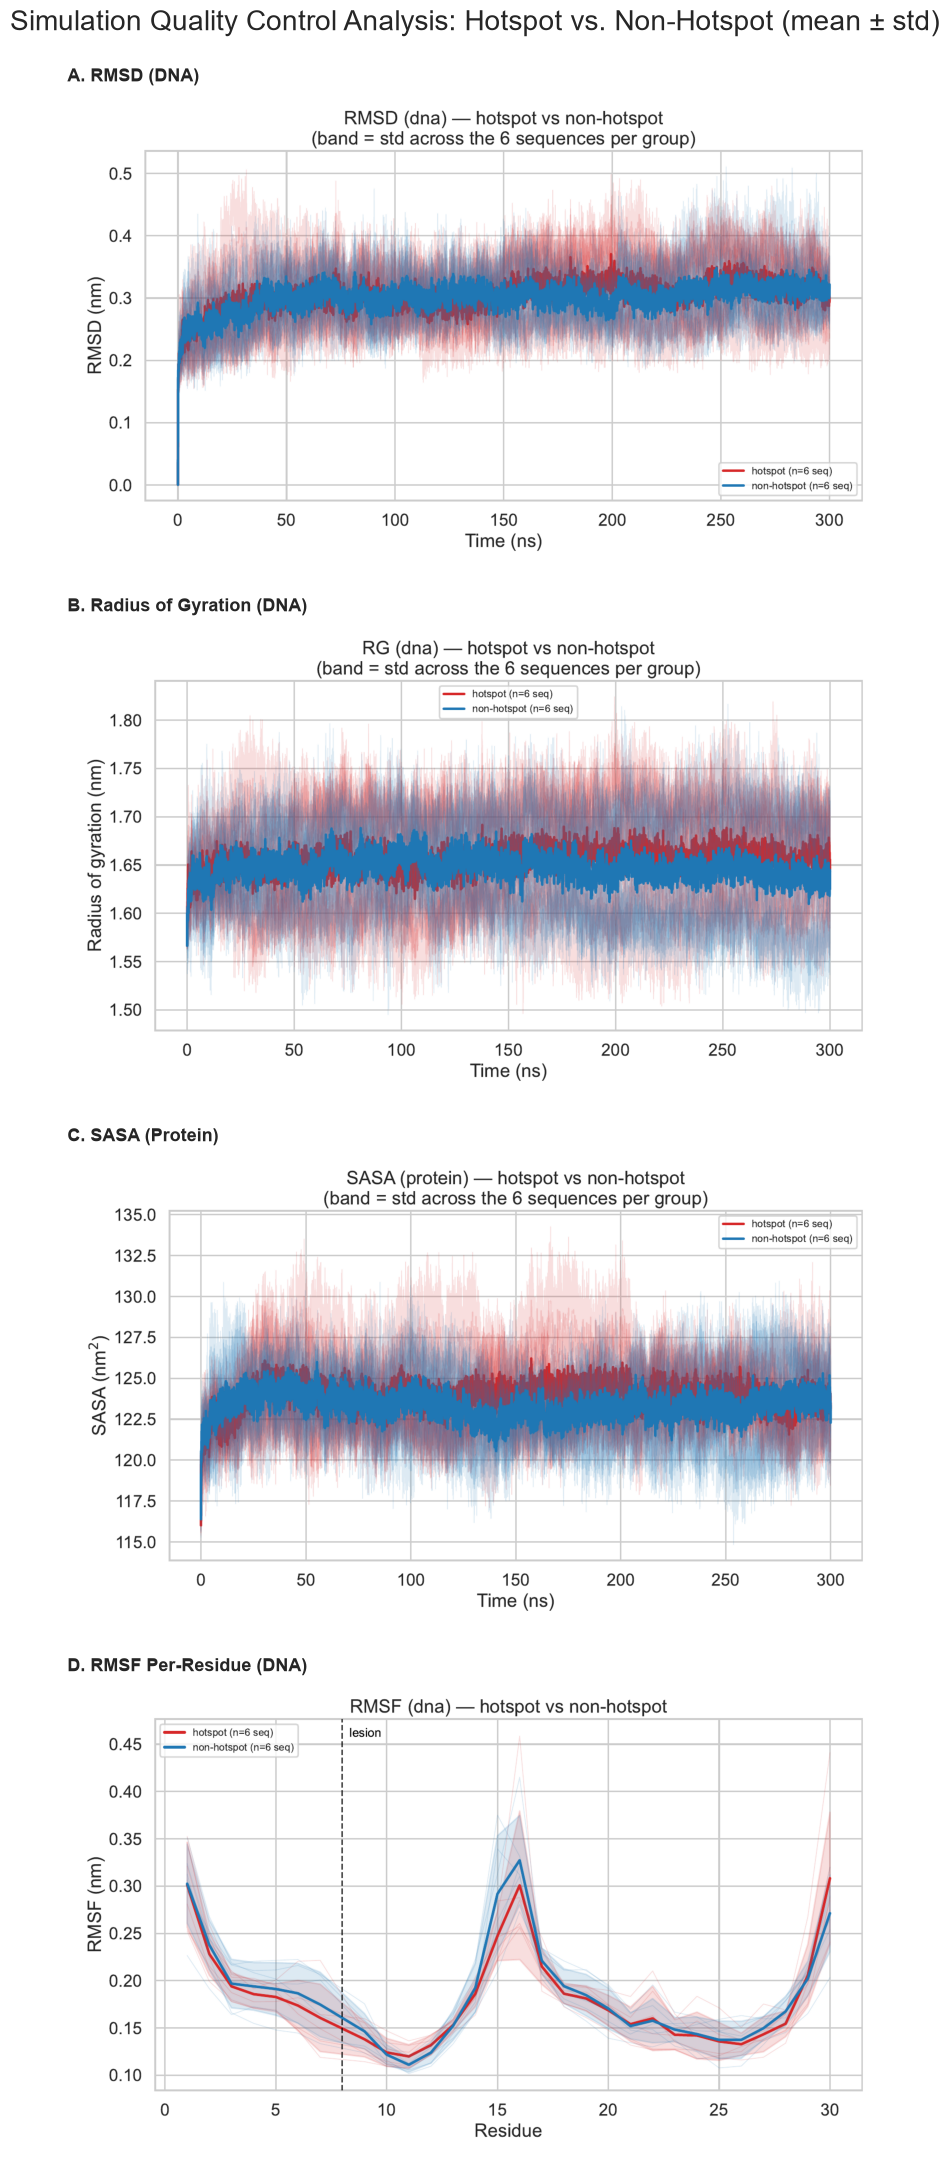

In [114]:
SOURCE_PDFS_GROUP = {
    "A": ("rmsd_dna_group_timeseries.pdf", "RMSD (DNA)"),
    "B": ("rg_dna_group_timeseries.pdf", "Radius of Gyration (DNA)"),
    "C": ("sasa_protein_group_timeseries.pdf", "SASA (Protein)"),
    "D": ("rmsf_dna_group_perresidue.pdf", "RMSF Per-Residue (DNA)"),
}

fig, axes = plt.subplots(4, 1, figsize=(9, 22))
for ax, panel in zip(axes.flat, ["A", "B", "C", "D"]):
    fname, label = SOURCE_PDFS_GROUP[panel]
    pages = convert_from_path(DYNAMICS_DIR / fname, dpi=150)
    ax.imshow(pages[0])
    ax.axis("off")
    ax.set_title(f"{panel}. {label}", fontsize=13, fontweight="bold", loc="left")
fig.suptitle("Simulation Quality Control Analysis: Hotspot vs. Non-Hotspot (mean \u00b1 std)", fontsize=20, y=0.99)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig2b_qc_composite_grouped.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 3 — Global dynamics: hotspot vs. non-hotspot (9 panels)

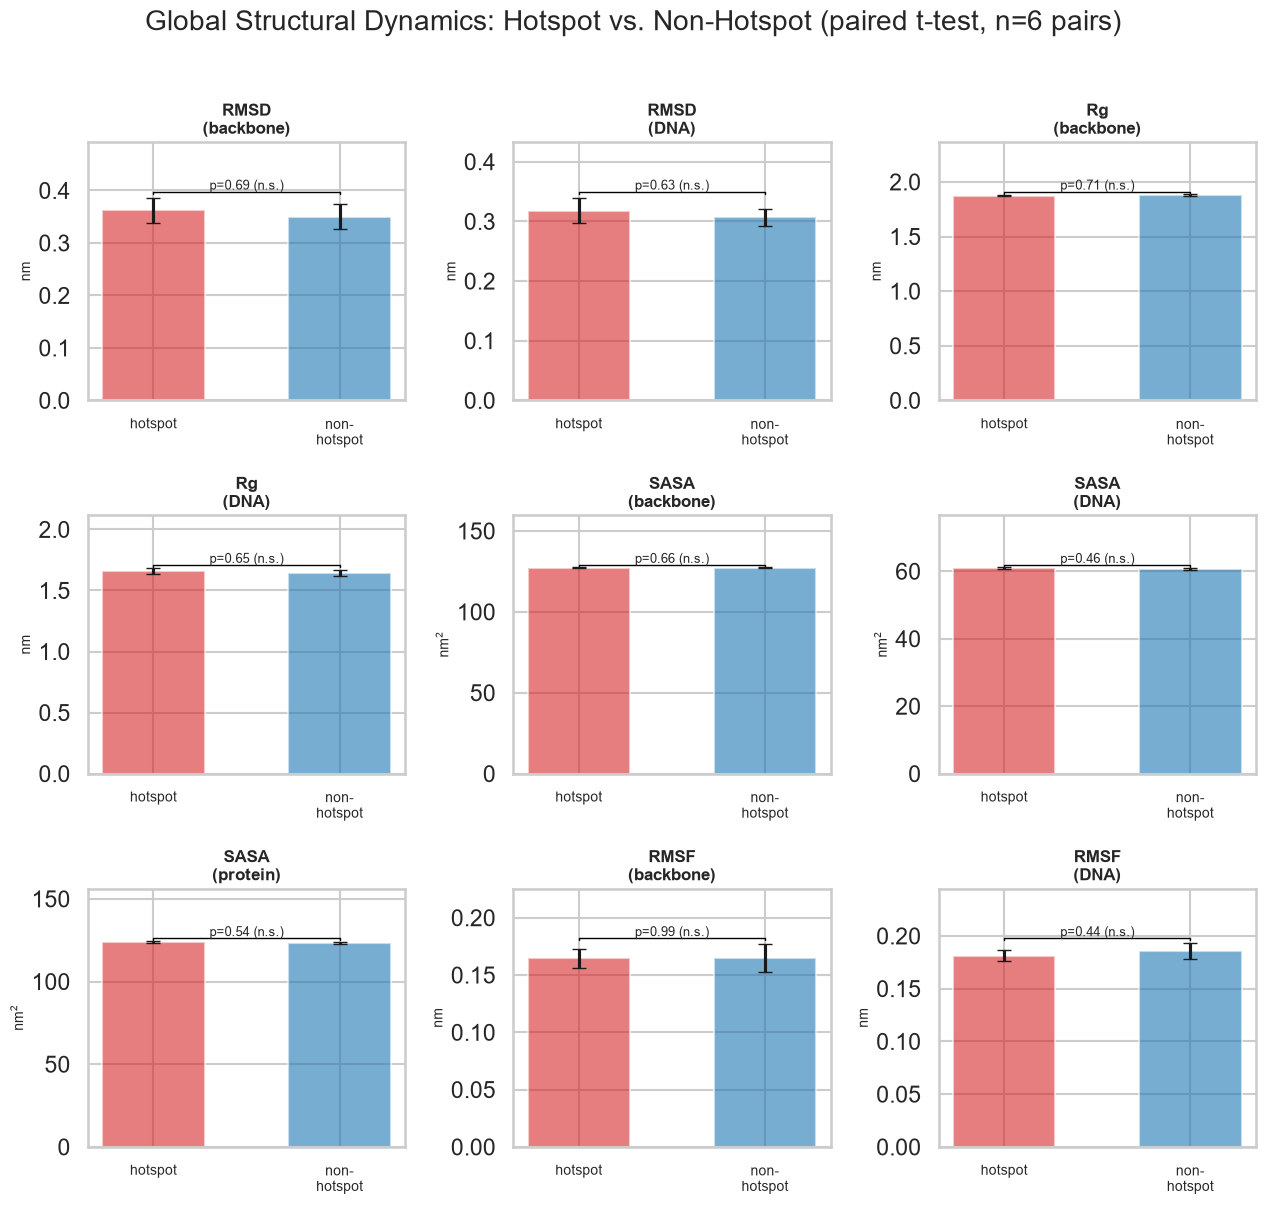

In [68]:
LABELS = {
    ("rmsd", "backbone"): "RMSD\n(backbone)", ("rmsd", "dna"): "RMSD\n(DNA)",
    ("rg", "backbone"): "Rg\n(backbone)", ("rg", "dna"): "Rg\n(DNA)",
    ("sasa", "backbone"): "SASA\n(backbone)", ("sasa", "dna"): "SASA\n(DNA)",
    ("sasa", "protein"): "SASA\n(protein)", ("rmsf", "backbone"): "RMSF\n(backbone)",
    ("rmsf", "dna"): "RMSF\n(DNA)",
}
UNITS = {"rmsd": "nm", "rg": "nm", "sasa": "nm$^2$", "rmsf": "nm"}
ORDER = list(LABELS.keys())

df3 = pd.read_csv(DYNAMICS_DIR / "dynamics_group_comparison_stats.csv").set_index(["metric", "component"])

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for ax, key in zip(axes.flat, ORDER):
    metric, component = key
    row = df3.loc[key]
    means, sems = [row["mean_hotspot"], row["mean_nonhotspot"]], [row["sem_hotspot"], row["sem_nonhotspot"]]
    ax.bar([0, 1], means, yerr=sems, capsize=5, color=[HOTSPOT_COLOUR, NONHOTSPOT_COLOUR], alpha=0.6, width=0.55, zorder=2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["hotspot", "non-\nhotspot"], fontsize=10)
    ax.set_ylabel(UNITS[metric], fontsize=10)
    ax.set_title(LABELS[key], fontsize=12, fontweight="bold")
    y_max = max(means[0] + sems[0], means[1] + sems[1])
    y_min = min(means[0] - sems[0], means[1] - sems[1])
    span = (y_max - y_min) if y_max > y_min else y_max
    bracket_y = y_max + span * 0.15
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.01, bracket_y * 1.01, bracket_y], color="black", lw=1)
    p_val = row["p_value"]
    stars = "n.s." if p_val >= 0.05 else ("*" if p_val >= 0.01 else "**")
    ax.text(0.5, bracket_y * 1.02, f"p={p_val:.2f} ({stars})", ha="center", fontsize=9, transform=ax.transData)
    ax.set_ylim(top=bracket_y * 1.25)
fig.suptitle("Global Structural Dynamics: Hotspot vs. Non-Hotspot (paired t-test, n=6 pairs)", fontsize=20, y=1.01)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig3_dynamics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 4 — Mean helical geometry by base-pair step

saved fig4_parameter_heatmap.png

Peak |z| per parameter:
  Twist (°)              max|z|=0.55 at step 8-9
  Roll (°)               max|z|=1.33 at step 7-8
  Rise (Å)               max|z|=0.72 at step 7-8
  Minor groove
width (Å) max|z|=2.08 at step 8-9
  Major groove
width (Å) max|z|=0.55 at step 13-14
  Shift (Å)              max|z|=1.54 at step 6-7
  Slide (Å)              max|z|=2.02 at step 8-9
  Tilt (°)               max|z|=0.53 at step 6-7
  Opening (°)            max|z|=1.95 at step 8-9
  Buckle (°)             max|z|=0.93 at step 10-11


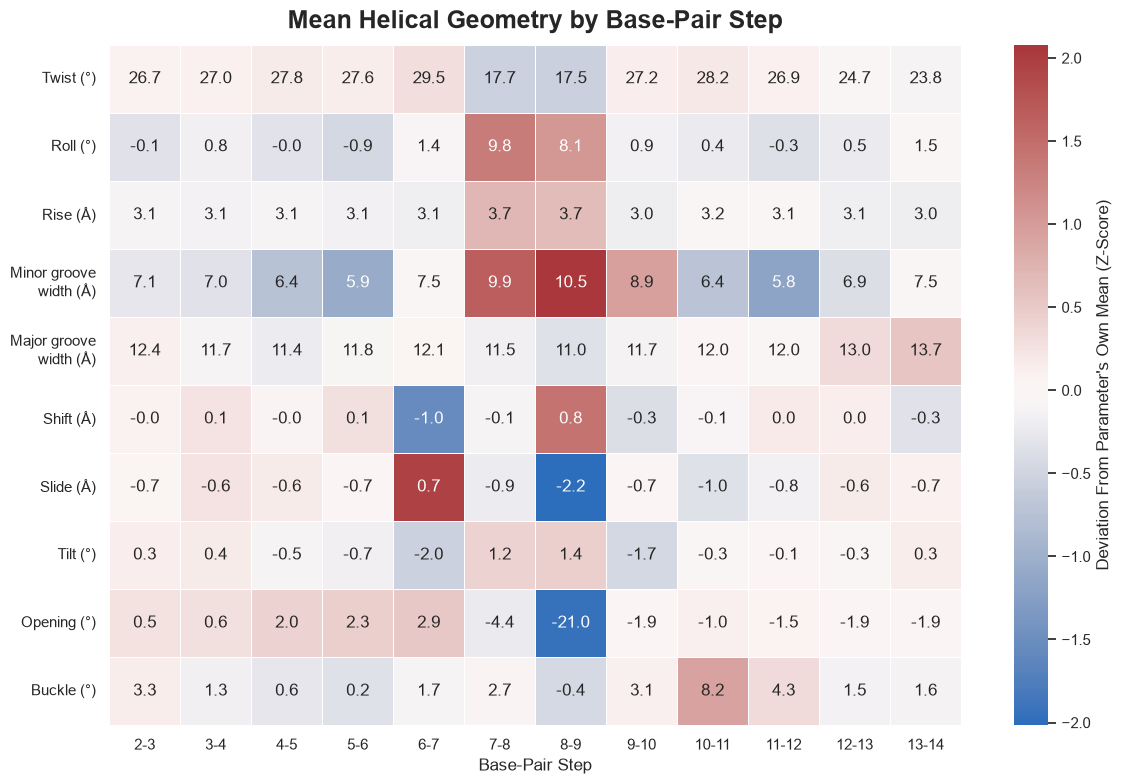

In [98]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")


KEY_PARAMS = ["twist", "roll", "rise", "minw", "majw", "shift", "slide", "tilt", "opening", "buckle"]
PARAM_LABELS = {
    "twist": "Twist (\u00b0)", "roll": "Roll (\u00b0)", "rise": "Rise (\u00c5)",
    "minw": "Minor groove\nwidth (\u00c5)", "majw": "Major groove\nwidth (\u00c5)",
    "shift": "Shift (\u00c5)", "slide": "Slide (\u00c5)", "tilt": "Tilt (\u00b0)",
    "opening": "Opening (\u00b0)", "buckle": "Buckle (\u00b0)",
}

df = pd.read_csv("merged_output.csv")
feature_cols = [c for c in df.columns if c != "sequence"]

means = df[feature_cols].mean()
stds = df[feature_cols].std()

records = []
for col in feature_cols:
    m = re.match(r"^(\d+)-(\d+)_(.+)$", col)
    if not m:
        continue
    start, end, param = int(m.group(1)), int(m.group(2)), m.group(3)
    if param in KEY_PARAMS:
        records.append({"step": f"{start}-{end}", "step_start": start, "param": param,
                         "value": means[col], "std": stds[col]})

long_df = pd.DataFrame(records)
step_order = sorted(long_df["step"].unique(), key=lambda s: int(s.split("-")[0]))
pivot = long_df.pivot(index="param", columns="step", values="value").reindex(
    index=KEY_PARAMS, columns=step_order
)

# Pooled noise estimate per parameter: average of its 12 per-step standard
# deviations, giving a stable measure of how much this parameter naturally
# fluctuates between simulations, independent of any one step's estimate.
pooled_std = long_df.groupby("param")["std"].mean().reindex(KEY_PARAMS)
row_mean = pivot.mean(axis=1)
pivot_z = pivot.sub(row_mean, axis=0).div(pooled_std, axis=0)

pivot.index = [PARAM_LABELS[p] for p in pivot.index]
pivot_z.index = pivot.index

z_bound = np.ceil(pivot_z.abs().max().max() * 10) / 10  # symmetric bound, e.g. 2.08 -> 2.1

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_z, annot=pivot.round(1), fmt="", cmap="vlag", center=0,
            cbar_kws={"label": "Deviation From Parameter's Own Mean (Z-Score)"},
            linewidths=0.5, linecolor="white", ax=ax)

# Mark the damaged base (position 8), which sits between the 7-8 and 8-9 steps
lesion_idx = step_order.index("7-8") + 1
ax.axvline(x=lesion_idx, color="black", linestyle="--", linewidth=1.5, zorder=10)

# Label it above the heatmap, outside the plot area
from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax.transData, ax.transAxes)
#ax.annotate("Damaged base\n(position 8)", xy=(lesion_idx, 1.0), xycoords=trans,
        #    xytext=(lesion_idx, 1.06), textcoords=trans,
        #    ha="center", va="bottom", fontsize=10, fontweight="bold",
        #    annotation_clip=False)

ax.set_xlabel("Base-Pair Step")
ax.set_ylabel("")
ax.set_title("Mean Helical Geometry by Base-Pair Step", fontsize=18, fontweight="bold", pad=28)
fig.savefig(FIG_OUT_DIR / "fig4_mean_helical_geometry.png", dpi=300, bbox_inches="tight")
plt.setp(ax.get_yticklabels(), rotation=0)

## Figure 5 — Classification performance (RF/SVM/XGBoost)

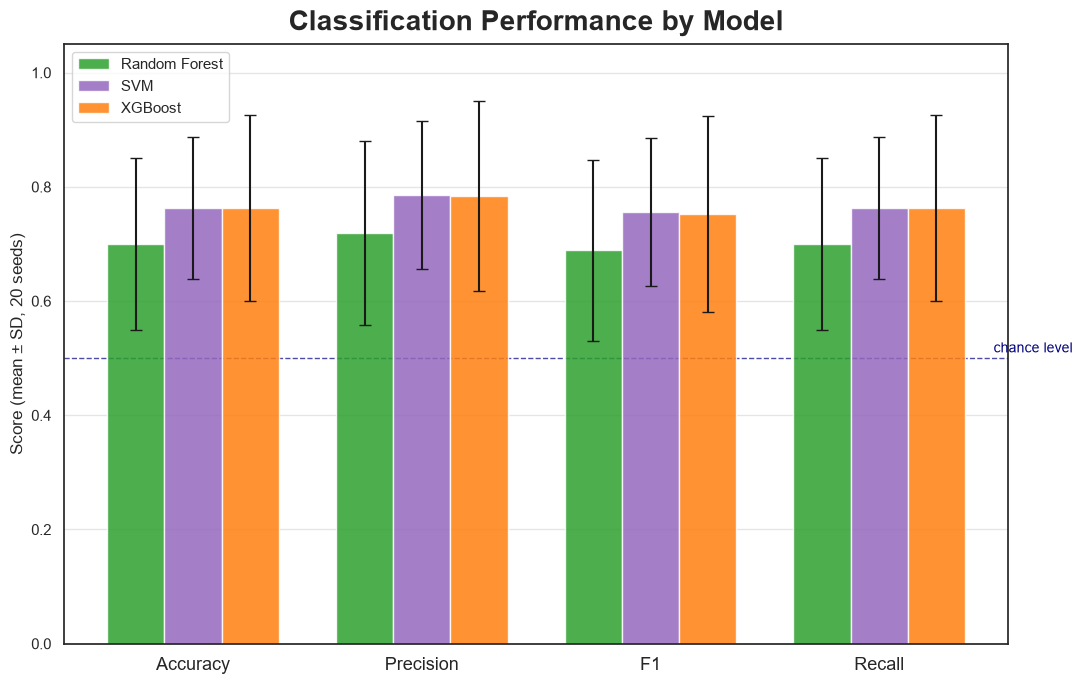

In [93]:
MODEL_COLOURS = {"Random Forest": "#2ca02c", "SVM": "#9467bd", "XGBoost": "#ff7f0e"}
METRICS = ["Accuracy", "Precision", "F1", "Recall"]

rf = pd.read_csv(PERFORMANCE_DIR / "RF_performance.csv").set_index("Metric")
svm = pd.read_csv(PERFORMANCE_DIR / "SVM_performance.csv").set_index("Metric")
xgb = pd.read_csv(PERFORMANCE_DIR / "XGB_performance.csv").set_index("Metric")
models = {"Random Forest": rf, "SVM": svm, "XGBoost": xgb}

fig, ax = plt.subplots(figsize=(11, 7))
bar_width = 0.25
x = np.arange(len(METRICS))
for i, (name, dframe) in enumerate(models.items()):
    means = [dframe.loc[m, "Mean"] for m in METRICS]
    stds = [dframe.loc[m, "Std"] for m in METRICS]
    offset = (i - 1) * bar_width
    ax.bar(x + offset, means, bar_width, yerr=stds, capsize=4, label=name, color=MODEL_COLOURS[name], alpha=0.85, zorder=2)
ax.axhline(0.5, color="navy", linestyle="--", lw=1, alpha=0.7, zorder=1)
ax.text(len(METRICS) - 0.5, 0.505, "chance level", fontsize=10, color="navy", va="bottom")
ax.set_xticks(x); ax.set_xticklabels(METRICS, fontsize=13)
ax.set_ylabel("Score (mean \u00b1 SD, 20 seeds)"); ax.set_ylim(0, 1.05)
ax.set_title("Classification Performance by Model", fontsize=20, fontweight="bold", pad=10)
ax.legend(fontsize=11, loc="upper left")
oob_mean, oob_std = rf.loc["OOB_Score", "Mean"], rf.loc["OOB_Score", "Std"]
#ax.text(0.01, 0.03, f"RF out-of-bag score: {oob_mean:.3f} \u00b1 {oob_std:.3f} (no SVM/XGBoost equivalent)",
#        transform=ax.transAxes, fontsize=10, style="italic", color="#2ca02c")
ax.grid(axis="y", color="grey", linestyle="-", alpha=0.2, zorder=0)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig5_classification_performance.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 6 — Feature selection convergence heatmap (positionally ordered)

saved fig6_convergence_heatmap.png


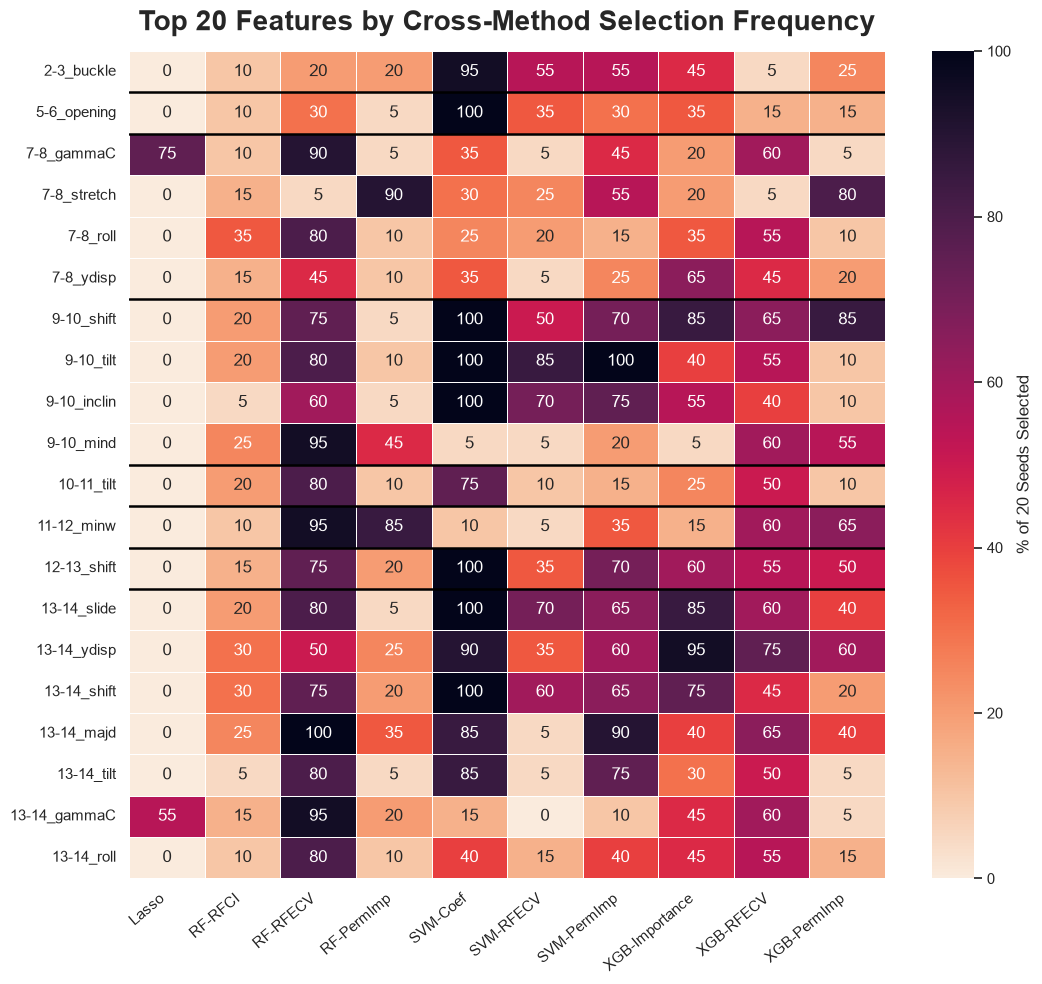

In [96]:
METHOD_FILES = {
    "Lasso": FEATURE_SELECTION_DIR / "shared" / "Lasso" / "Lasso_summary.csv",
    "RF-RFCI": FEATURE_SELECTION_DIR / "rf" / "RFCI" / "RF_RFCI_summary.csv",
    "RF-RFECV": FEATURE_SELECTION_DIR / "rf" / "RFECV" / "RF_RFECV_summary.csv",
    "RF-PermImp": FEATURE_SELECTION_DIR / "rf" / "PermImportance" / "RF_PermImportance_summary.csv",
    "SVM-Coef": FEATURE_SELECTION_DIR / "svm" / "SVMCoef" / "SVM_SVMCoef_summary.csv",
    "SVM-RFECV": FEATURE_SELECTION_DIR / "svm" / "RFECV" / "SVM_RFECV_summary.csv",
    "SVM-PermImp": FEATURE_SELECTION_DIR / "svm" / "PermImportance" / "SVM_PermImportance_summary.csv",
    "XGB-Importance": FEATURE_SELECTION_DIR / "xgb" / "XGBImportance" / "XGB_XGBImportance_summary.csv",
    "XGB-RFECV": FEATURE_SELECTION_DIR / "xgb" / "RFECV" / "XGB_RFECV_summary.csv",
    "XGB-PermImp": FEATURE_SELECTION_DIR / "xgb" / "PermImportance" / "XGB_PermImportance_summary.csv",
}

method_series = {}
for name, fname in METHOD_FILES.items():
    df = pd.read_csv(fname)
    method_series[name] = df.set_index("Feature")["pct_of_runs"]

all_features = sorted(set().union(*[s.index for s in method_series.values()]))
matrix = pd.DataFrame(0.0, index=all_features, columns=method_series.keys())
for name, s in method_series.items():
    matrix.loc[s.index, name] = s.values

n_methods_hit = (matrix > 0).sum(axis=1)
total_pct = matrix.sum(axis=1)
ranked_features = sorted(matrix.index, key=lambda f: (-n_methods_hit[f], -total_pct[f]))
top_20_features = ranked_features[:20]

def _parse_step_start(feature_name):
    return int(feature_name.split("-", 1)[0])

# PRIMARY: step position (ascending). SECONDARY: total selection strength
# (descending) - the strongest feature at each position listed first.
display_order = sorted(top_20_features, key=lambda f: (_parse_step_start(f), -total_pct[f]))
top_features = matrix.loc[display_order]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(top_features, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=100,
            cbar_kws={"label": "% of 20 Seeds Selected"}, linewidths=0.5, linecolor="white", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Top 20 Features by Cross-Method Selection Frequency",
             fontsize=20, fontweight="bold", pad=15)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")

# Draw a dark separator line at each step-block boundary
step_starts = [_parse_step_start(f) for f in display_order]
for i in range(1, len(step_starts)):
    if step_starts[i] != step_starts[i - 1]:
        ax.axhline(i, color="black", lw=1.8)

fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig6_convergence_heatmap.png", dpi=300, bbox_inches="tight")
print("saved fig6_convergence_heatmap.png")

## Figure 7 — PCA scatter: true label vs. K-means cluster assignment

C:\Users\rache\AppData\Local\Temp\ipykernel_32764\302297407.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df7 = df7.assign(base_sequence=base_sequence, hotspot=base_sequence.map(hotspot_map))
C:\Users\rache\AppData\Local\Temp\ipykernel_32764\302297407.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df7 = df7.assign(base_sequence=base_sequence, hotspot=base_sequence.map(hotspot_map))


saved fig7_pca_scatter.png


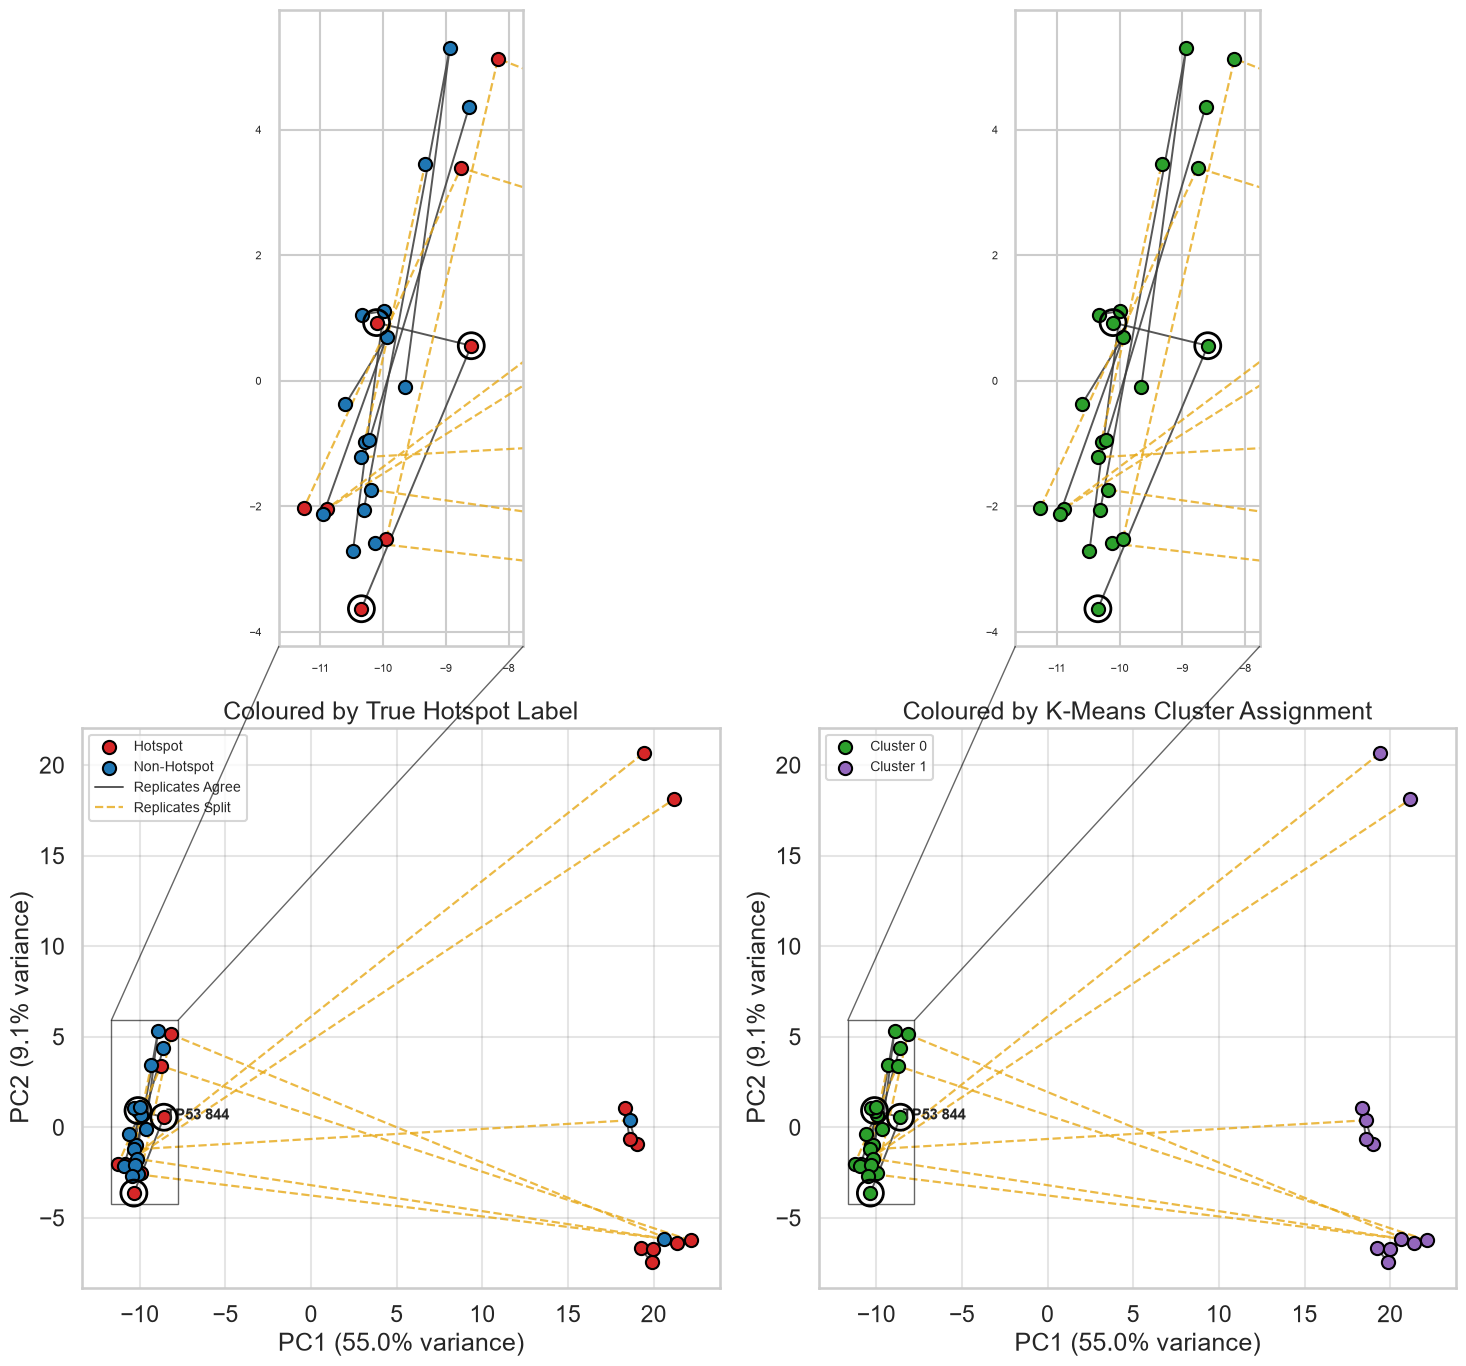

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from matplotlib.patches import Rectangle, ConnectionPatch


CLUSTER_COLOURS = ["#2ca02c", "#9467bd"]
UNANIMOUS_COLOUR = "#3a3a3a"
SPLIT_COLOUR = "#e6a817"
HIGHLIGHT_SEQUENCE = "TP53_844"

df7 = pd.read_csv(MERGED_OUTPUT_PATH)
base_sequence = df7["sequence"].str.rsplit("_", n=1).str[0]
df7 = df7.assign(base_sequence=base_sequence, hotspot=base_sequence.map(hotspot_map))
assert df7["hotspot"].isnull().sum() == 0, "sequence naming doesn't match hotspot_map"

X = df7.drop(columns=["sequence", "base_sequence", "hotspot"])
y7 = df7["hotspot"].to_numpy()

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=12, random_state=159625)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=159625)
cluster_labels = kmeans.fit_predict(X_pca)
acc_as_is = (cluster_labels == y7).mean()
acc_flipped = ((1 - cluster_labels) == y7).mean()
if acc_flipped > acc_as_is:
    cluster_labels = 1 - cluster_labels
aligned_accuracy = max(acc_as_is, acc_flipped)

pc1, pc2 = X_pca[:, 0], X_pca[:, 1]
var1, var2 = pca.explained_variance_ratio_[0] * 100, pca.explained_variance_ratio_[1] * 100
var_12_combined = var1 + var2
var_12pc_total = pca.explained_variance_ratio_.sum() * 100

ZOOM_XLIM = (pc1[pc1 < 0].min() - 0.4, pc1[pc1 < 0].max() + 0.4)
ZOOM_YLIM = (pc2[pc1 < 0].min() - 0.6, pc2[pc1 < 0].max() + 0.6)
ZOOM_ASPECT = (ZOOM_YLIM[1] - ZOOM_YLIM[0]) / (ZOOM_XLIM[1] - ZOOM_XLIM[0])

def draw_points(ax, colour_by):
    for base_seq in df7["base_sequence"].unique():
        mask = df7["base_sequence"] == base_seq
        seq_clusters = cluster_labels[mask.values]
        is_split = len(set(seq_clusters)) > 1
        line_colour = SPLIT_COLOUR if is_split else UNANIMOUS_COLOUR
        line_style = "--" if is_split else "-"
        line_width = 1.6 if is_split else 1.4
        line_alpha = 0.8 if is_split else 0.85
        ax.plot(pc1[mask], pc2[mask], color=line_colour, ls=line_style, lw=line_width,
                 alpha=line_alpha, zorder=2 if is_split else 1)

    if colour_by == "label":
        for label, colour, name in [(1, HOTSPOT_COLOUR, "Hotspot"), (0, NONHOTSPOT_COLOUR, "Non-Hotspot")]:
            mask = y7 == label
            ax.scatter(pc1[mask], pc2[mask], color=colour, s=90, edgecolor="black", zorder=3, label=name)
    else:
        for cluster in [0, 1]:
            mask = cluster_labels == cluster
            ax.scatter(pc1[mask], pc2[mask], color=CLUSTER_COLOURS[cluster], s=90, edgecolor="black",
                         zorder=3, label=f"Cluster {cluster}")

    hl_mask = df7["base_sequence"] == HIGHLIGHT_SEQUENCE
    ax.scatter(pc1[hl_mask], pc2[hl_mask], s=350, facecolors="none", edgecolors="black", linewidths=2, zorder=4)

def add_zoom_indicator(main_ax, inset_ax, xlim, ylim):
    """Draws the zoom-region rectangle on main_ax and connects its TOP two
    corners straight up to the BOTTOM two corners of inset_ax - since the
    inset sits directly above main_ax now, this keeps the connectors
    vertical instead of indicate_inset_zoom's default corner-matching,
    which produces a crossing 'X' when the inset isn't diagonally offset."""
    main_ax.add_patch(Rectangle((xlim[0], ylim[0]), xlim[1] - xlim[0], ylim[1] - ylim[0],
                                  fill=False, edgecolor="black", alpha=0.6, lw=1, zorder=5))
    for x_data, x_frac in [(xlim[0], 0.0), (xlim[1], 1.0)]:
        con = ConnectionPatch(xyA=(x_data, ylim[1]), coordsA="data", axesA=main_ax,
                                xyB=(x_frac, 0.0), coordsB="axes fraction", axesB=inset_ax,
                                color="black", alpha=0.6, lw=1)
        main_ax.figure.add_artist(con)

fig, big_axes = plt.subplots(2, 2, figsize=(15, 14), gridspec_kw={"height_ratios": [2.5, 2.2]})
(inset0, inset1), (axes0, axes1) = big_axes
axes = [axes0, axes1]

draw_points(axes[0], "label")
axes[0].plot([], [], color=UNANIMOUS_COLOUR, lw=1.4, alpha=0.85, label="Replicates Agree")
axes[0].plot([], [], color=SPLIT_COLOUR, ls="--", lw=1.6, alpha=0.8, label="Replicates Split")
axes[0].set_title("Coloured by True Hotspot Label", fontsize=18)

draw_points(axes[1], "cluster")
axes[1].set_title("Coloured by K-Means Cluster Assignment", fontsize=18)

hl_mask = df7['base_sequence'] == HIGHLIGHT_SEQUENCE
for ax in axes:
    ax.annotate(HIGHLIGHT_SEQUENCE.replace('_', ' '), xy=(pc1[hl_mask].mean(), pc2[hl_mask].mean()),
                xytext=(15, 15), textcoords="offset points", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var1:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var2:.1f}% variance)")
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(axis="both", color="grey", linestyle="-", alpha=0.2, zorder=0)
# Insets now live in their own row above the main panels, not floating on
# top of the data - fixes both the overlap and keeps the labelling consistent
# across both panels (previously only panel B had the TP53_844 text label).
draw_points(inset0, "label")
inset0.set_xlim(*ZOOM_XLIM)
inset0.set_ylim(*ZOOM_YLIM)
inset0.set_box_aspect(ZOOM_ASPECT)
inset0.tick_params(labelsize=8)
#inset0.set_title("Zoom: crowded region", fontsize=10)
add_zoom_indicator(axes[0], inset0, ZOOM_XLIM, ZOOM_YLIM)

draw_points(inset1, "cluster")
inset1.set_xlim(*ZOOM_XLIM)
inset1.set_ylim(*ZOOM_YLIM)
inset1.set_box_aspect(ZOOM_ASPECT)
inset1.tick_params(labelsize=8)
#inset1.set_title("Zoom: crowded region", fontsize=10)
add_zoom_indicator(axes[1], inset1, ZOOM_XLIM, ZOOM_YLIM)

fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig7_pca_scatter.png", dpi=300, bbox_inches="tight")
print("saved fig7_pca_scatter.png")

saved fig7_pca_scatter.png


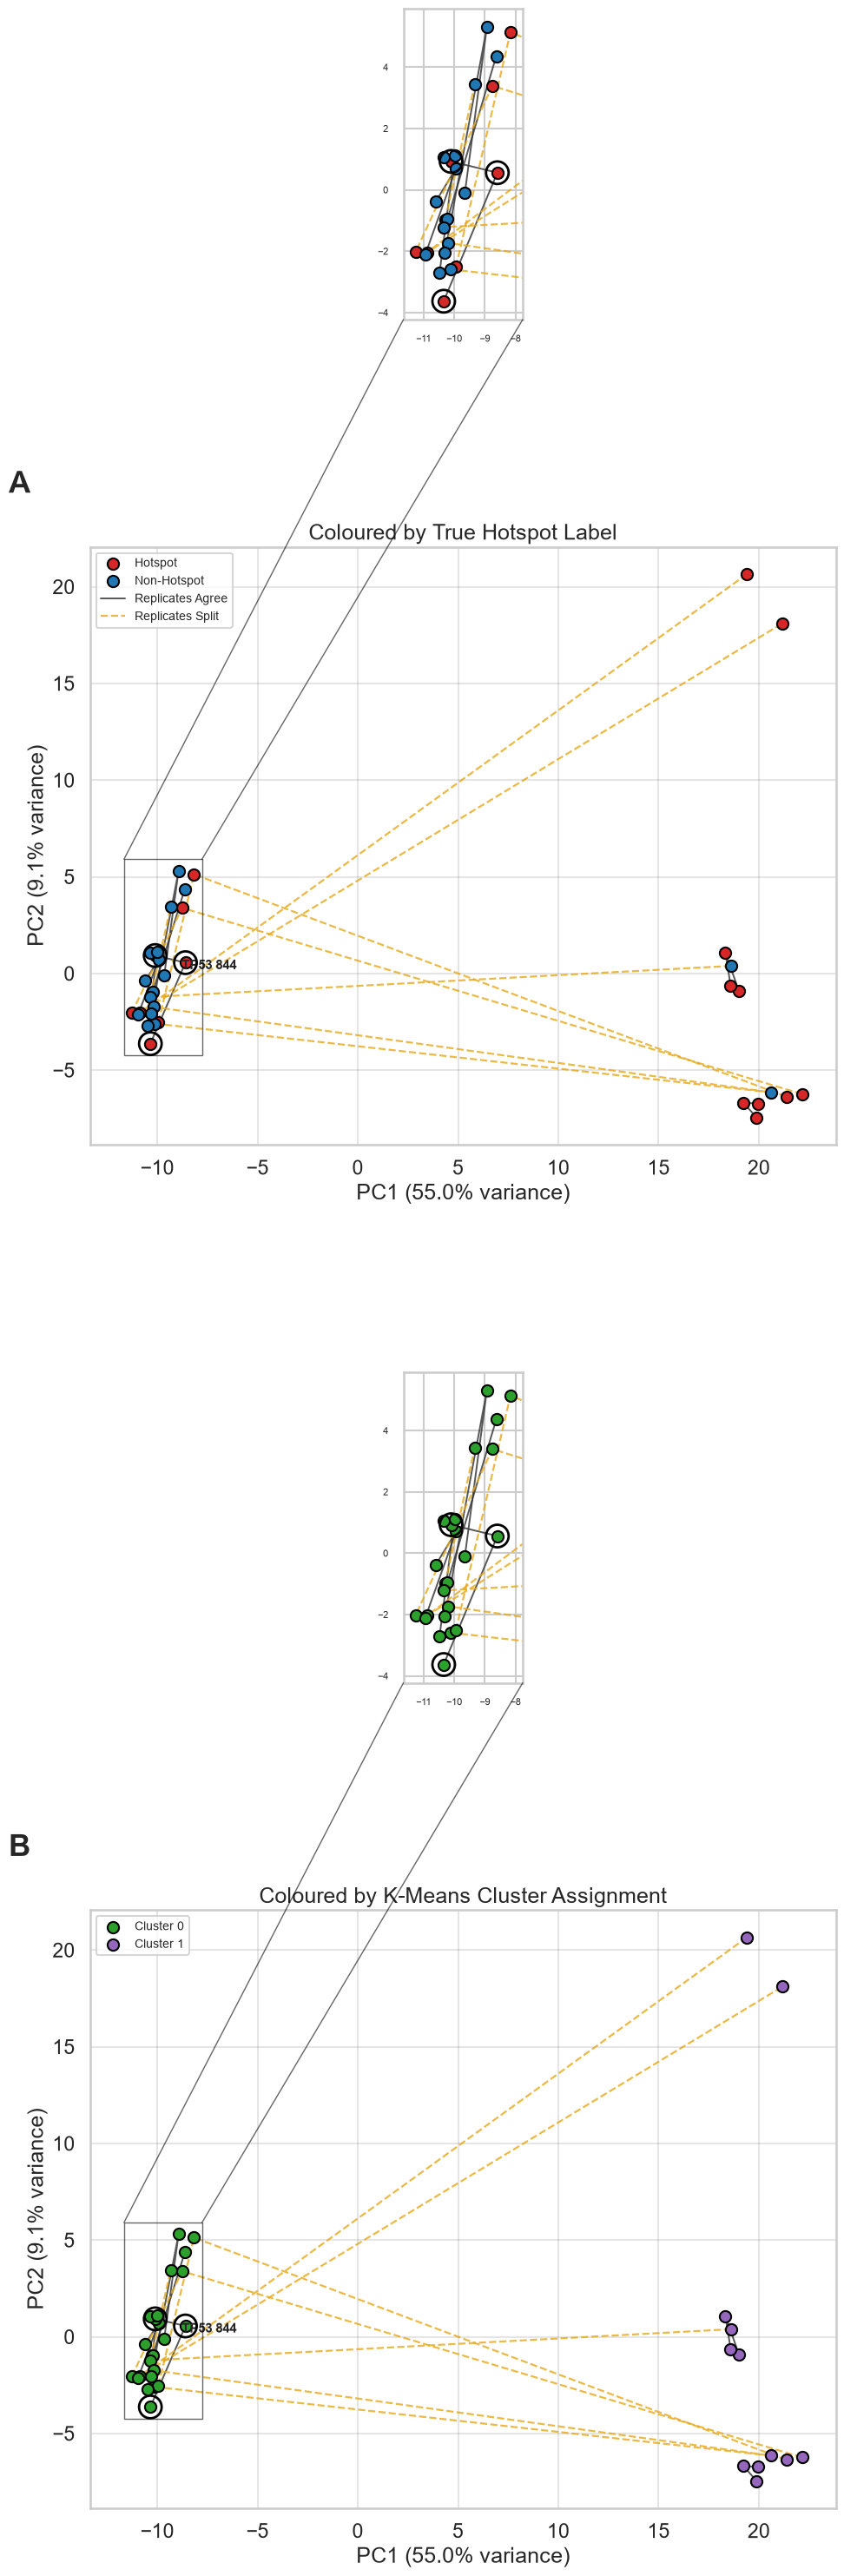

In [123]:
fig, (inset0, axes0, inset1, axes1) = plt.subplots(
    4, 1, figsize=(10, 30), gridspec_kw={"height_ratios": [1.3, 2.5, 1.3, 2.5]}
)
axes = [axes0, axes1]

draw_points(axes[0], "label")
axes[0].plot([], [], color=UNANIMOUS_COLOUR, lw=1.4, alpha=0.85, label="Replicates Agree")
axes[0].plot([], [], color=SPLIT_COLOUR, ls="--", lw=1.6, alpha=0.8, label="Replicates Split")
axes[0].set_title("Coloured by True Hotspot Label", fontsize=18)
axes[0].text(-0.08, 1.08, "A", transform=axes[0].transAxes, fontsize=25, fontweight="bold", va="bottom", ha="right")


draw_points(axes[1], "cluster")
axes[1].set_title("Coloured by K-Means Cluster Assignment", fontsize=18)
axes[1].text(-0.08, 1.08, "B", transform=axes[1].transAxes, fontsize=25, fontweight="bold", va="bottom", ha="right")

hl_mask = df7['base_sequence'] == HIGHLIGHT_SEQUENCE
for ax in axes:
    ax.annotate(HIGHLIGHT_SEQUENCE.replace('_', ' '), xy=(pc1[hl_mask].mean(), pc2[hl_mask].mean()),
                xytext=(15, 15), textcoords="offset points", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var1:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var2:.1f}% variance)")
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(axis="both", color="grey", linestyle="-", alpha=0.2, zorder=0)

# Insets now sit directly above their own main panel in the same single
# column, rather than in a separate row - fixes the overlap and keeps
# labelling consistent across both panels.
draw_points(inset0, "label")
inset0.set_xlim(*ZOOM_XLIM)
inset0.set_ylim(*ZOOM_YLIM)
inset0.set_box_aspect(ZOOM_ASPECT)
inset0.tick_params(labelsize=8)
#inset0.set_title("Zoom: crowded region", fontsize=10)
add_zoom_indicator(axes[0], inset0, ZOOM_XLIM, ZOOM_YLIM)

draw_points(inset1, "cluster")
inset1.set_xlim(*ZOOM_XLIM)
inset1.set_ylim(*ZOOM_YLIM)
inset1.set_box_aspect(ZOOM_ASPECT)
inset1.tick_params(labelsize=8)
#inset1.set_title("Zoom: crowded region", fontsize=10)
add_zoom_indicator(axes[1], inset1, ZOOM_XLIM, ZOOM_YLIM)

fig.tight_layout()
fig.subplots_adjust(hspace=0.5)
fig.savefig(FIG_OUT_DIR / "fig7_pca_scatter.png", dpi=300, bbox_inches="tight")
print("saved fig7_pca_scatter.png")

## Figure 7b - Unsupervised Feature Selection

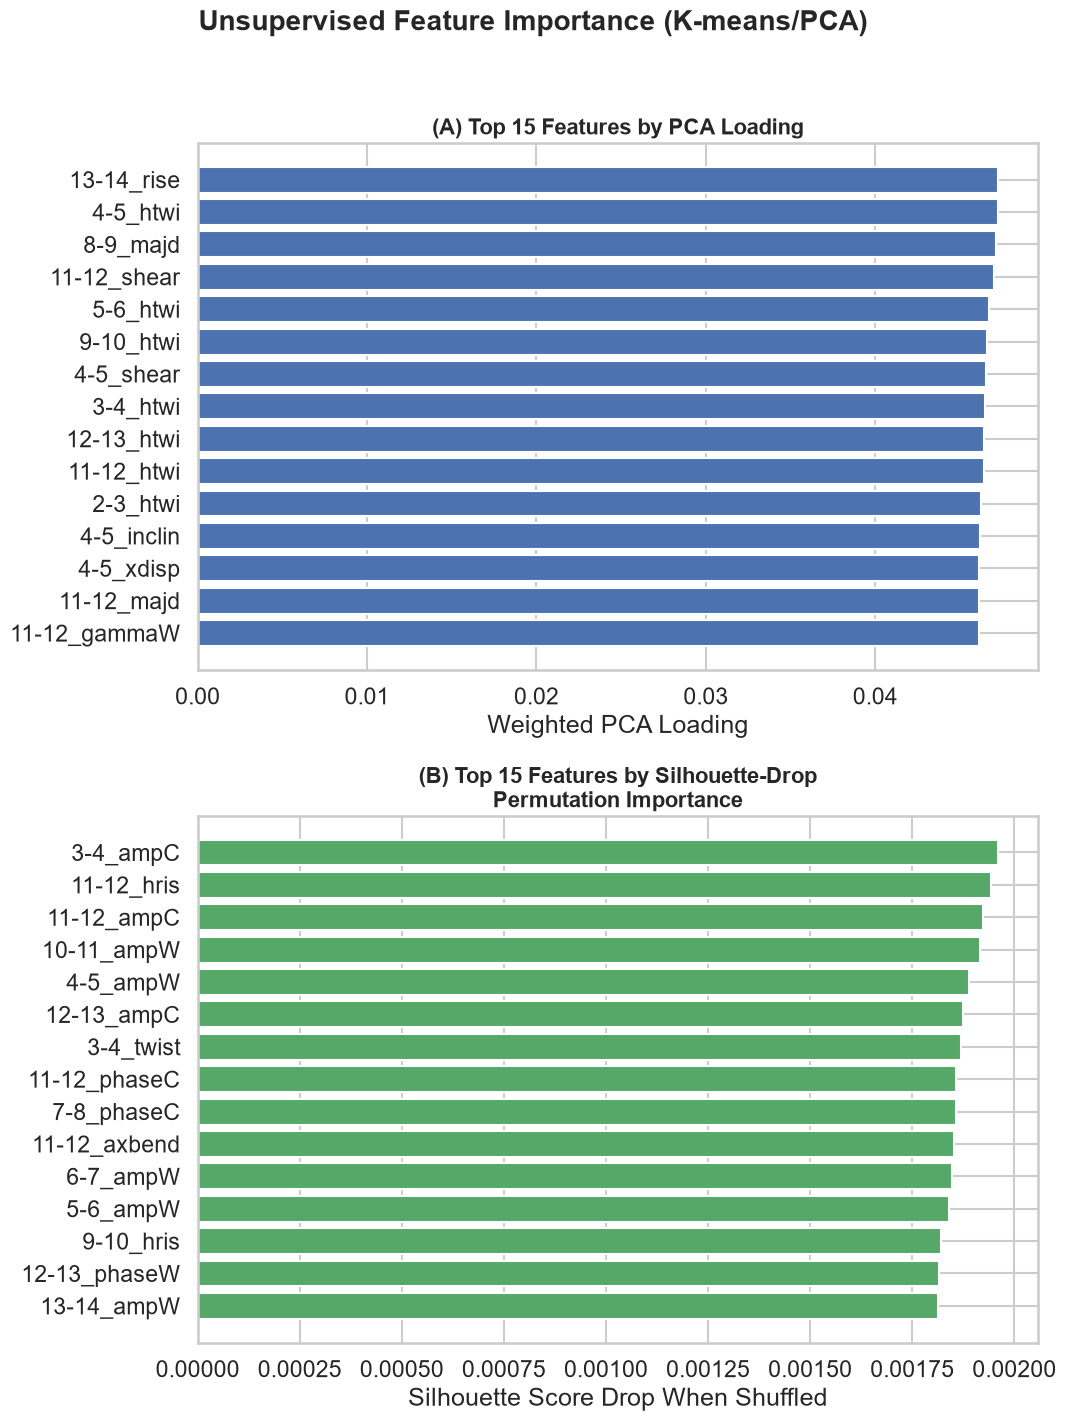

In [120]:
loadings = pd.read_csv(FEATURE_SELECTION_DIR / "kmeans" / "PCALoadings" / "KMeans_PCALoadings.csv").sort_values("WeightedLoading", ascending=False).head(15)
silhouette = pd.read_csv(FEATURE_SELECTION_DIR / "kmeans" / "SilhouettePermImportance" / "KMeans_SilhouettePermImportance.csv").sort_values("SilhouetteDrop", ascending=False).head(15)

fig, axes = plt.subplots(2, 1, figsize=(11, 14))

axes[0].barh(loadings["Feature"][::-1], loadings["WeightedLoading"][::-1], color="#4c72b0")
axes[0].set_xlabel("Weighted PCA Loading")
axes[0].set_title("(A) Top 15 Features by PCA Loading", fontsize=16, fontweight="bold")

axes[1].barh(silhouette["Feature"][::-1], silhouette["SilhouetteDrop"][::-1], color="#55a868")
axes[1].set_xlabel("Silhouette Score Drop When Shuffled")
axes[1].set_title("(B) Top 15 Features by Silhouette-Drop\nPermutation Importance", fontsize=16, fontweight="bold")

fig.suptitle("Unsupervised Feature Importance (K-means/PCA)", fontsize=20, y=1.02,  fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig7b_unsupervised_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 8 — RING contact analysis: 10-metric null result

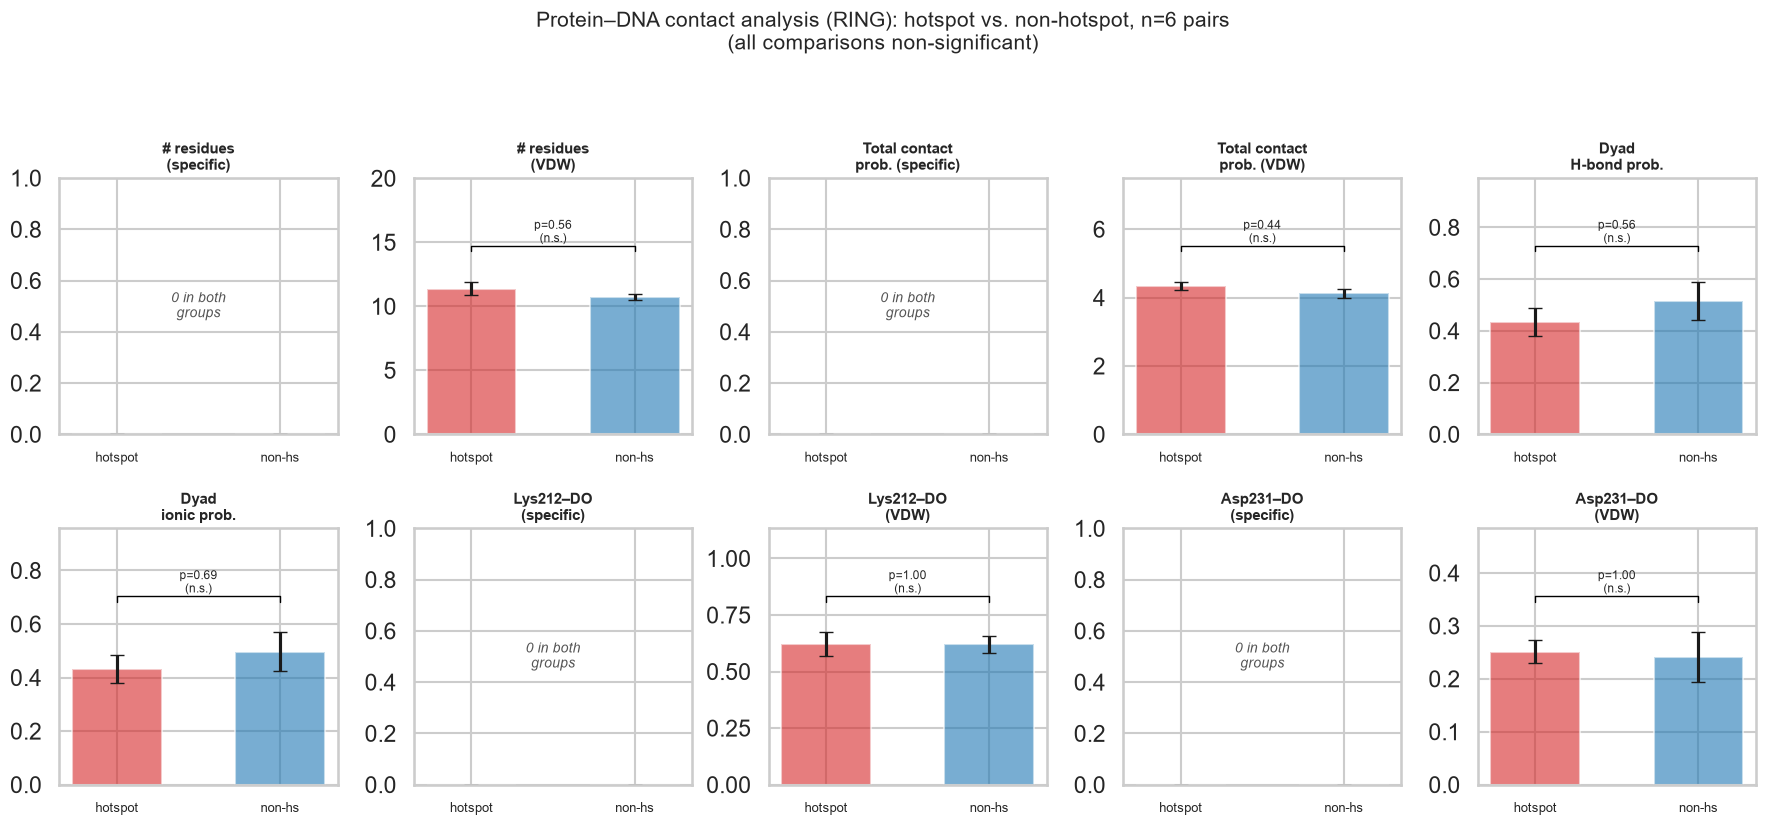

In [41]:
METRIC_LABELS = {
    "n_residues_contacting_DO_specific": "# residues\n(specific)",
    "n_residues_contacting_DO_vdw": "# residues\n(VDW)",
    "total_DO_contact_probability_specific": "Total contact\nprob. (specific)",
    "total_DO_contact_probability_vdw": "Total contact\nprob. (VDW)",
    "dyad_hbond_prob": "Dyad\nH-bond prob.",
    "dyad_ionic_prob": "Dyad\nionic prob.",
    "Lys212_DO_prob_specific": "Lys212\u2013DO\n(specific)",
    "Lys212_DO_prob_vdw": "Lys212\u2013DO\n(VDW)",
    "Asp231_DO_prob_specific": "Asp231\u2013DO\n(specific)",
    "Asp231_DO_prob_vdw": "Asp231\u2013DO\n(VDW)",
}
ORDER8 = list(METRIC_LABELS.keys())

stats_df = pd.read_csv(RING_DIR / "hotspot_vs_nonhotspot_stats.csv").set_index("metric")
per_seq = pd.read_csv(RING_DIR / "per_sequence_averaged.csv")
sem_hot = per_seq[per_seq.hotspot == 1][ORDER8].sem()
sem_non = per_seq[per_seq.hotspot == 0][ORDER8].sem()

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, metric in zip(axes.flat, ORDER8):
    row = stats_df.loc[metric]
    means = [row["mean_hotspot"], row["mean_nonhotspot"]]
    sems = [sem_hot[metric], sem_non[metric]]
    ax.bar([0, 1], means, yerr=sems, capsize=5, color=[HOTSPOT_COLOUR, NONHOTSPOT_COLOUR], alpha=0.6, width=0.55, zorder=2)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["hotspot", "non-hs"], fontsize=9)
    ax.set_title(METRIC_LABELS[metric], fontsize=10.5, fontweight="bold")

    is_all_zero = (means[0] == 0) and (means[1] == 0)
    if is_all_zero:
        ax.set_ylim(0, 1)
        ax.text(0.5, 0.5, "0 in both\ngroups", ha="center", va="center", fontsize=10, color="#555555",
                transform=ax.transAxes, style="italic")
        continue

    y_max = max((means[0] + (sems[0] or 0)), (means[1] + (sems[1] or 0)), 0.01)
    bracket_y = y_max * 1.2
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y], color="black", lw=1)
    p_val = row["p_value"]
    stars = "n.s." if p_val >= 0.05 else ("*" if p_val >= 0.01 else "**")
    ax.text(0.5, bracket_y * 1.05, f"p={p_val:.2f}\n({stars})", ha="center", fontsize=8.5, transform=ax.transData)
    ax.set_ylim(0, bracket_y * 1.4)

fig.suptitle("Protein\u2013DNA contact analysis (RING): hotspot vs. non-hotspot, n=6 pairs\n(all comparisons non-significant)",
             fontsize=15, y=1.04)
fig.tight_layout()
fig.savefig(FIG_OUT_DIR / "fig8_ring_null_result.png", dpi=200, bbox_inches="tight")
plt.show()
